# 01 - Data Profiling and Quality Assessment

Profiling of the raw Victoria Road Crash Data files before any schema design.
The goal is to measure data quality issues, not to fix them here - fixes are
implemented in the ETL pipeline (Phase 5) based on the rules in
[`docs/data_quality_assessment.md`](../docs/data_quality_assessment.md).

All files are read as text so nothing is silently converted.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../data/raw") if Path("../data/raw").exists() else Path("data/raw")


def load_raw(name: str) -> pd.DataFrame:
    return pd.read_csv(RAW_DIR / f"{name}.csv", dtype=str, keep_default_na=False, na_values=[""])


accident = load_raw("accident")
person = load_raw("person")
vehicle = load_raw("vehicle")
node = load_raw("node")
lite = load_raw("victorian_road_crash_data")
atmospheric = load_raw("atmospheric_cond")
surface = load_raw("road_surface_cond")
sub_dca = load_raw("sub_dca")

pd.DataFrame(
    {name: [len(df), df.shape[1]] for name, df in {
        "accident": accident, "person": person, "vehicle": vehicle, "node": node,
        "lite": lite, "atmospheric": atmospheric, "surface": surface, "sub_dca": sub_dca,
    }.items()},
    index=["rows", "columns"],
).T

,rows,columns
accident,200754,23
person,467730,14
vehicle,365470,37
node,405918,11
lite,200754,52
atmospheric,202905,4
surface,201829,4
sub_dca,287521,4


## 1. Crash identifiers, dates and times

In [2]:
crash_dates = pd.to_datetime(accident["ACCIDENT_DATE"], format="%Y-%m-%d", errors="coerce")
crash_times = pd.to_datetime(accident["ACCIDENT_TIME"], format="%H:%M:%S", errors="coerce")

pd.Series({
    "duplicate ACCIDENT_NO": accident["ACCIDENT_NO"].duplicated().sum(),
    "ACCIDENT_NO not matching T + 11 digits": (~accident["ACCIDENT_NO"].str.fullmatch(r"T\d{11}")).sum(),
    "unparseable dates": crash_dates.isna().sum(),
    "unparseable times": crash_times.isna().sum(),
    "earliest date": crash_dates.min().date(),
    "latest date": crash_dates.max().date(),
    "times recorded as exactly 00:00:00": (accident["ACCIDENT_TIME"] == "00:00:00").sum(),
})

duplicate ACCIDENT_NO                              0
ACCIDENT_NO not matching T + 11 digits             0
unparseable dates                                  0
unparseable times                                  0
earliest date                             2012-01-01
latest date                               2026-01-31
times recorded as exactly 00:00:00               113
dtype: object

The year inside `ACCIDENT_NO` is not always the crash year, so the ID must not be
used to derive dates.

In [3]:
id_year = accident["ACCIDENT_NO"].str[1:5].astype(int)
(id_year - crash_dates.dt.year).value_counts().sort_index().rename("id_year minus crash_year")

-1         1
 0    196125
 1      4312
 2       215
 3        88
 4         9
 5         2
 6         1
 7         1
Name: id_year minus crash_year, dtype: int64

Times cluster on the hour and half hour, which suggests many times are estimated
or rounded by the reporter. Hour-level analysis is fine; minute-level is not.

In [4]:
accident["ACCIDENT_TIME"].str[3:5].value_counts().head(5).rename("crashes by minute value")

ACCIDENT_TIME
00    32898
30    29163
45    13391
15    12740
20    11671
Name: crashes by minute value, dtype: int64

## 2. Completeness of recent months

The dataset is published with a lag. Monthly counts show whether the most recent
months are complete enough for trend analysis.

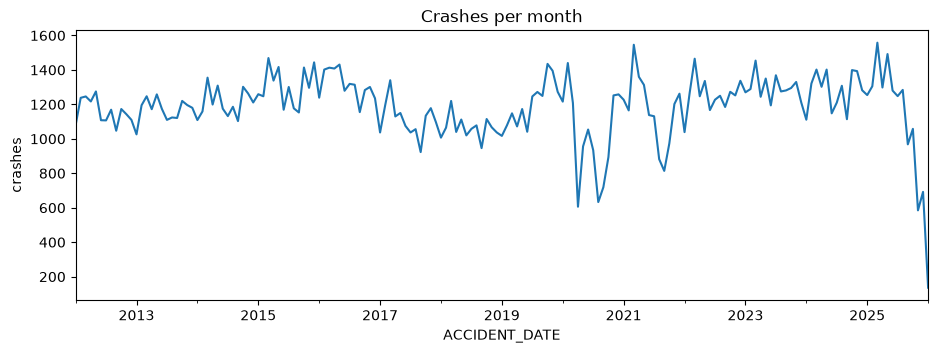

ACCIDENT_DATE
2025-04    1298
2025-05    1492
2025-06    1280
2025-07    1248
2025-08    1284
2025-09     968
2025-10    1058
2025-11     585
2025-12     692
2026-01     136
Freq: M, Name: count, dtype: int64

In [5]:
monthly = crash_dates.dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 3.5))
monthly.plot(ax=ax)
ax.set_title("Crashes per month")
ax.set_ylabel("crashes")
plt.show()

monthly.tail(10)

## 3. Day of week: code vs description vs actual date

In [6]:
actual_weekday = crash_dates.dt.day_name()
print("DAY_WEEK_DESC matches the weekday of ACCIDENT_DATE:",
      f"{(actual_weekday == accident['DAY_WEEK_DESC']).mean():.2%}")
pd.crosstab(accident["DAY_OF_WEEK"], accident["DAY_WEEK_DESC"])

DAY_WEEK_DESC matches the weekday of ACCIDENT_DATE: 100.00%


DAY_WEEK_DESC,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
DAY_OF_WEEK,,,,,,,
0,0,0,0,4653,0,0,0
1,0,5646,0,19689,0,0,0
2,0,21664,0,0,0,6204,0
3,0,0,0,0,0,22863,6435
4,0,0,0,0,6358,0,23620
5,6663,0,0,0,24009,0,0
6,24936,0,5513,0,0,0,0
7,0,0,22501,0,0,0,0


## 4. Numeric fields and internal consistency of the crash table

In [7]:
count_columns = ["NO_OF_VEHICLES", "NO_PERSONS_KILLED", "NO_PERSONS_INJ_2",
                 "NO_PERSONS_INJ_3", "NO_PERSONS_NOT_INJ", "NO_PERSONS"]
counts = accident[count_columns].astype(int)
severity = accident["SEVERITY"]

pd.Series({
    "negative counts": (counts < 0).sum().sum(),
    "NO_PERSONS != sum of injury-level counts": (
        counts["NO_PERSONS"] != counts[count_columns[1:5]].sum(axis=1)).sum(),
    "crashes with 0 vehicles": (counts["NO_OF_VEHICLES"] == 0).sum(),
    "fatal severity but nobody killed": ((severity == "1") & (counts["NO_PERSONS_KILLED"] == 0)).sum(),
    "someone killed but not fatal severity": ((severity != "1") & (counts["NO_PERSONS_KILLED"] > 0)).sum(),
    "serious severity but no serious injuries": ((severity == "2") & (counts["NO_PERSONS_INJ_2"] == 0)).sum(),
})

negative counts                             0
NO_PERSONS != sum of injury-level counts    0
crashes with 0 vehicles                     6
fatal severity but nobody killed            0
someone killed but not fatal severity       0
serious severity but no serious injuries    1
dtype: int64

`SPEED_ZONE` is stored with leading zeros and contains values that are not speeds.

In [8]:
accident["SPEED_ZONE"].value_counts()

SPEED_ZONE
060    65413
050    33043
080    30447
100    28284
999    13261
040    12968
070    12556
110     2088
888     1344
090      505
030      426
777      399
075       20
Name: count, dtype: int64

## 5. Severity scope

Severity 4 (non-injury) is almost absent, so this dataset describes **injury
crashes**, not all crashes.

In [9]:
lite["SEVERITY"].value_counts()

SEVERITY
Other injury accident      125154
Serious injury accident     72225
Fatal accident               3371
Non injury accident             4
Name: count, dtype: int64

## 6. node.csv: duplicates and conflicting attributes

In [10]:
node_dedup = node.drop_duplicates()
rows_per_crash = node_dedup.groupby("ACCIDENT_NO").size()

pd.Series({
    "raw rows": len(node),
    "exact duplicate rows": node.duplicated().sum(),
    "rows after removing exact duplicates": len(node_dedup),
    "crashes with more than one distinct NODE_ID": (node_dedup.groupby("ACCIDENT_NO")["NODE_ID"].nunique() > 1).sum(),
    "crashes still having more than one row": (rows_per_crash > 1).sum(),
})

raw rows                                       405918
exact duplicate rows                           202505
rows after removing exact duplicates           203413
crashes with more than one distinct NODE_ID         0
crashes still having more than one row           3137
dtype: int64

In [11]:
conflicting = node_dedup[node_dedup["ACCIDENT_NO"].duplicated(keep=False)]
attribute_columns = [c for c in node_dedup.columns if c != "ACCIDENT_NO"]
differing = conflicting.groupby("ACCIDENT_NO")[attribute_columns].nunique(dropna=False).gt(1).sum()
print("Columns that differ within the same crash:")
print(differing[differing > 0])

conflicting.groupby("ACCIDENT_NO")["DEG_URBAN_NAME"].apply(
    lambda s: " / ".join(sorted(s.dropna()))).value_counts().head()

Columns that differ within the same crash:
DEG_URBAN_NAME    3137
dtype: int64


DEG_URBAN_NAME
MELB_URBAN / RURAL_VICTORIA      1117
MELBOURNE_CBD / MELB_URBAN        844
RURAL_VICTORIA / SMALL_CITIES     373
RURAL_VICTORIA / TOWNS            324
MELB_URBAN / SMALL_TOWNS          170
Name: count, dtype: int64

Does the one-row-per-crash lite file agree with node.csv, and which
`DEG_URBAN_NAME` does it pick for the conflicting crashes?

In [12]:
lite_by_crash = lite.set_index("ACCIDENT_NO")
node_first = node_dedup.drop_duplicates("ACCIDENT_NO").set_index("ACCIDENT_NO").reindex(lite_by_crash.index)

lat_diff = (pd.to_numeric(node_first["LATITUDE"]) - pd.to_numeric(lite_by_crash["LATITUDE"])).abs()
lon_diff = (pd.to_numeric(node_first["LONGITUDE"]) - pd.to_numeric(lite_by_crash["LONGITUDE"])).abs()
lite_pick_in_node = conflicting.groupby("ACCIDENT_NO")["DEG_URBAN_NAME"].apply(set).to_frame().join(
    lite_by_crash["DEG_URBAN_NAME"].rename("lite_value")
).apply(lambda row: row["lite_value"] in row["DEG_URBAN_NAME"], axis=1)

pd.Series({
    "crashes with coordinates in both files": (lat_diff.notna()).sum(),
    "coordinates differing by > 0.0001 deg": ((lat_diff > 1e-4) | (lon_diff > 1e-4)).sum(),
    "crashes missing from node.csv": node_first["LATITUDE"].isna().sum(),
    "crashes with no coordinates in lite file": lite_by_crash["LATITUDE"].isna().sum(),
    "conflicting crashes where lite value is one of the node values": lite_pick_in_node.sum(),
    "conflicting crashes total": len(lite_pick_in_node),
})

crashes with coordinates in both files                            200267
coordinates differing by > 0.0001 deg                                  0
crashes missing from node.csv                                        487
crashes with no coordinates in lite file                              85
conflicting crashes where lite value is one of the node values      3137
conflicting crashes total                                           3137
dtype: int64

## 7. Coordinates

In [13]:
# Approximate bounding box of Victoria, with a small margin.
VIC_LAT_RANGE = (-39.3, -33.9)
VIC_LON_RANGE = (140.9, 150.1)

latitude = pd.to_numeric(lite["LATITUDE"], errors="coerce")
longitude = pd.to_numeric(lite["LONGITUDE"], errors="coerce")
outside = ~latitude.between(*VIC_LAT_RANGE) | ~longitude.between(*VIC_LON_RANGE)

pd.Series({
    "missing coordinates": latitude.isna().sum(),
    "non-numeric coordinates": (latitude.isna() & lite["LATITUDE"].notna()).sum(),
    "zero coordinates": ((latitude == 0) | (longitude == 0)).sum(),
    "outside Victoria bounding box": (outside & latitude.notna()).sum(),
    "latitude range": f"{latitude.min()} to {latitude.max()}",
    "longitude range": f"{longitude.min()} to {longitude.max()}",
})

missing coordinates                                   85
non-numeric coordinates                                0
zero coordinates                                       0
outside Victoria bounding box                          0
latitude range                   -39.03083 to -34.115696
longitude range                   140.96648 to 149.75746
dtype: object

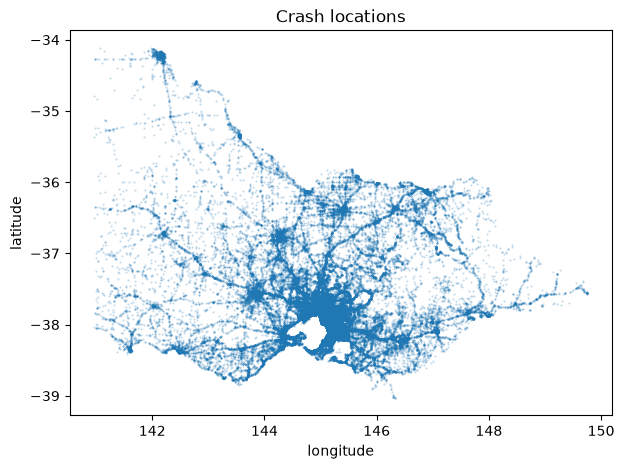

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(longitude, latitude, s=0.2, alpha=0.3)
ax.set_title("Crash locations")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.show()

LGA names in brackets are unincorporated areas (mostly alpine resorts), not councils.

In [15]:
lite.loc[lite["LGA_NAME"].str.startswith("(", na=False), "LGA_NAME"].value_counts()

LGA_NAME
(MOUNT HOTHAM)      53
(FALLS CREEK)       28
(LAKE MOUNTAIN)     25
(MOUNT BULLER)      23
(MOUNT BAW BAW)     14
(FRENCH ISLAND)      4
(MOUNT STIRLING)     2
Name: count, dtype: int64

## 8. Referential integrity

Orphans = child rows whose crash does not exist. Missing = crashes with no child rows.

In [16]:
crash_ids = set(accident["ACCIDENT_NO"])
crash_month = accident.set_index("ACCIDENT_NO")["ACCIDENT_DATE"].str[:7]
children = {"person": person, "vehicle": vehicle, "node": node, "atmospheric": atmospheric,
            "surface": surface, "sub_dca": sub_dca}

rows = []
for name, df in children.items():
    child_ids = set(df["ACCIDENT_NO"])
    missing = crash_ids - child_ids
    missing_months = crash_month.loc[list(missing)]
    rows.append({
        "table": name,
        "orphans": len(child_ids - crash_ids),
        "crashes with no rows": len(missing),
        "of which since 2025-08": (missing_months >= "2025-08").sum(),
        "busiest missing months": ", ".join(missing_months.value_counts().head(3).index),
    })
pd.DataFrame(rows)

,table,orphans,crashes with no rows,of which since 2025-08,busiest missing months
0,person,0,402,327,"2026-01, 2025-12, 2025-11"
1,vehicle,0,411,327,"2026-01, 2025-12, 2025-11"
2,node,0,487,327,"2026-01, 2025-12, 2025-11"
3,atmospheric,0,402,327,"2026-01, 2025-12, 2025-11"
4,surface,0,0,0,
5,sub_dca,0,1276,327,"2014-06, 2014-05, 2014-07"


## 9. Cross-table consistency (crash counts vs detail rows)

In [17]:
crash_counts = accident.set_index("ACCIDENT_NO")[["NO_PERSONS", "NO_PERSONS_KILLED", "NO_OF_VEHICLES"]].astype(int)
detail_counts = pd.DataFrame({
    "person_rows": person.groupby("ACCIDENT_NO").size(),
    "fatal_person_rows": person[person["INJ_LEVEL"] == "1"].groupby("ACCIDENT_NO").size(),
    "vehicle_rows": vehicle.groupby("ACCIDENT_NO").size(),
})
compared = crash_counts.join(detail_counts, how="inner").fillna({"fatal_person_rows": 0})

pd.Series({
    "NO_PERSONS != person rows": (compared["NO_PERSONS"] != compared["person_rows"]).sum(),
    "NO_PERSONS_KILLED != fatal person rows": (compared["NO_PERSONS_KILLED"] != compared["fatal_person_rows"]).sum(),
    "NO_OF_VEHICLES != vehicle rows": (compared["NO_OF_VEHICLES"] != compared["vehicle_rows"].fillna(0)).sum(),
})

NO_PERSONS != person rows                 2
NO_PERSONS_KILLED != fatal person rows    0
NO_OF_VEHICLES != vehicle rows            5
dtype: int64

In [18]:
person_with_vehicle = person.dropna(subset=["VEHICLE_ID"])
vehicle_keys = set(vehicle["ACCIDENT_NO"] + "|" + vehicle["VEHICLE_ID"])
is_pedestrian = person["ROAD_USER_TYPE_DESC"] == "Pedestrians"

pd.Series({
    "person rows without VEHICLE_ID": person["VEHICLE_ID"].isna().sum(),
    "pedestrians": is_pedestrian.sum(),
    "pedestrians with a VEHICLE_ID": (is_pedestrian & person["VEHICLE_ID"].notna()).sum(),
    "non-pedestrians without a VEHICLE_ID": (~is_pedestrian & person["VEHICLE_ID"].isna()).sum(),
    "person -> vehicle references not found in vehicle.csv": (
        ~(person_with_vehicle["ACCIDENT_NO"] + "|" + person_with_vehicle["VEHICLE_ID"]).isin(vehicle_keys)).sum(),
})

person rows without VEHICLE_ID                           18776
pedestrians                                              18783
pedestrians with a VEHICLE_ID                               31
non-pedestrians without a VEHICLE_ID                        24
person -> vehicle references not found in vehicle.csv       39
dtype: int64

## 10. Multi-valued conditions

A crash can have more than one weather condition, surface condition or sub-DCA code.
This matters for the dimensional model: these cannot be simple one-per-crash attributes.

In [19]:
def multi_value_summary(df: pd.DataFrame, description_column: str) -> pd.Series:
    rows_per_crash = df.groupby("ACCIDENT_NO").size()
    return pd.Series({
        "crashes": len(rows_per_crash),
        "crashes with > 1 value": (rows_per_crash > 1).sum(),
        "max values per crash": rows_per_crash.max(),
        "most common combination": df[df["ACCIDENT_NO"].map(rows_per_crash) > 1]
            .groupby("ACCIDENT_NO")[description_column]
            .apply(lambda s: " + ".join(sorted(s))).value_counts().index[0],
    })


pd.DataFrame({
    "atmospheric": multi_value_summary(atmospheric, "ATMOSPH_COND_DESC"),
    "surface": multi_value_summary(surface, "SURFACE_COND_DESC"),
    "sub_dca": multi_value_summary(sub_dca, "SUB_DCA_CODE_DESC"),
})

,atmospheric,surface,sub_dca
crashes,200352,200754,199478
crashes with > 1 value,2509,1070,69683
max values per crash,4,3,7
most common combination,Clear + Strong winds,Muddy + Wet,Intersection + Vehicle entering intersection


## 11. Vehicle and person fields

In [20]:
manufacture_year = pd.to_numeric(vehicle["VEHICLE_YEAR_MANUF"], errors="coerce")

pd.Series({
    "VEHICLE_YEAR_MANUF blank": vehicle["VEHICLE_YEAR_MANUF"].isna().sum(),
    "VEHICLE_YEAR_MANUF = 0": (manufacture_year == 0).sum(),
    "VEHICLE_YEAR_MANUF in the future": (manufacture_year > 2026).sum(),
    "VEHICLE_POWER non-null": vehicle["VEHICLE_POWER"].notna().sum(),
    "AGE_GROUP 'Unknown'": (person["AGE_GROUP"] == "Unknown").sum(),
    "SEX 'U'": (person["SEX"] == "U").sum(),
})

VEHICLE_YEAR_MANUF blank             6951
VEHICLE_YEAR_MANUF = 0              31211
VEHICLE_YEAR_MANUF in the future        1
VEHICLE_POWER non-null                  0
AGE_GROUP 'Unknown'                 15129
SEX 'U'                             16675
dtype: int64

In [21]:
person.groupby(["ROAD_USER_TYPE", "ROAD_USER_TYPE_DESC"]).size()

ROAD_USER_TYPE  ROAD_USER_TYPE_DESC
1               Pedestrians             18783
16              E-scooter Rider           425
2               Drivers                295219
3               Passengers              94801
4               Motorcyclists           28740
5               Pillion Passengers       1018
6               Bicyclists              19883
7               Drivers                  1031
8               Passengers                449
9               Not Known                7381
dtype: int64

## Summary

Findings and the handling rule for each issue are recorded in
[`docs/data_quality_assessment.md`](../docs/data_quality_assessment.md).